In [1]:
import duckdb
import matplotlib.pyplot as plt

def q(sql):
    with duckdb.connect("../transform/interfood_dev.duckdb", read_only=True) as c:
        return c.sql(sql).df()

BLUE, ORANGE, GRAY = "#0072B2", "#D55E00", "#9AA0A6"

# Interfood case — market analysis

What the cleaned data says. All figures read from the dbt-built mart
(`fct_futures_prices`, USD/MT); no transformation happens in this notebook.

## 1. The SMP forward curve moved — but not uniformly

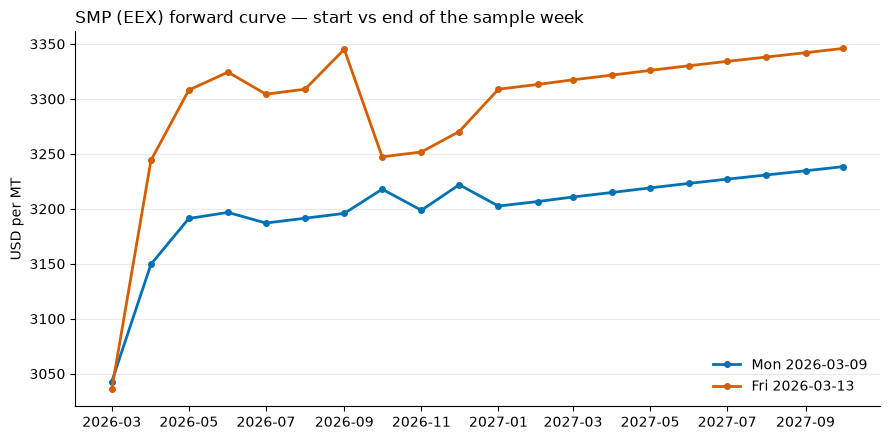

In [2]:
df = q('''
    select "Timestamp",
           make_date("Year", "Month", 1) as tenor,
           "PriceUSDMT"
    from fct_futures_prices
    where "Market" = 'EEX' and "Product" = 'SMP'
      and "Timestamp" in (date '2026-03-09', date '2026-03-13')
    order by tenor
''')

mon = df[df["Timestamp"] == df["Timestamp"].min()]
fri = df[df["Timestamp"] == df["Timestamp"].max()]

fig, ax = plt.subplots(figsize=(9, 4.5))
ax.plot(mon["tenor"], mon["PriceUSDMT"], color=BLUE,   lw=2, marker="o", ms=4, label="Mon 2026-03-09")
ax.plot(fri["tenor"], fri["PriceUSDMT"], color=ORANGE, lw=2, marker="o", ms=4, label="Fri 2026-03-13")
ax.set_title("SMP (EEX) forward curve — start vs end of the sample week", loc="left")
ax.set_ylabel("USD per MT")
ax.spines[["top", "right"]].set_visible(False)
ax.grid(axis="y", alpha=.25)
ax.legend(frameon=False)
plt.tight_layout()

Three observations from one picture:

1. **Contango.** Both curves slope upward — the market prices future SMP
   above prompt SMP, the usual carry-and-supply-expectation shape.
2. **A steepening week.** Friday's curve sits ~100 USD/MT above Monday's
   across the board, *except* at the front: MAR2026, weeks from expiry,
   stayed pinned near its Monday level (it actually eased slightly — the
   −1.75 USD/MT/day of required output 1). Near-dated contracts are anchored
   by imminent settlement against physical prices; the rest of the curve is
   free to reprice expectations.
3. **A mid-curve kink.** The rally is not parallel: SEP2026 gained the most
   (+149 USD/MT on the week) while OCT–DEC 2026 lagged (+29 to +53),
   leaving a visible dip. Dairy curves often carry seasonal-supply shapes;
   this sample is too small to attribute a cause, so we note the shape and
   stop there.

## 2. The week by tenor — one contract fell, nineteen rose

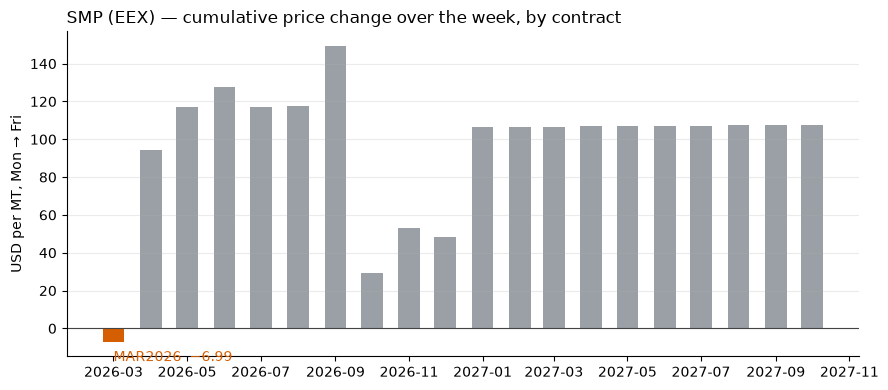

In [3]:
chg = q('''
    with daily as (
        select "Year", "Month",
            "PriceUSDMT" - lag("PriceUSDMT") over (
                partition by "Year", "Month" order by "Timestamp"
            ) as day_change
        from fct_futures_prices
        where "Market" = 'EEX' and "Product" = 'SMP'
    )
    select make_date("Year", "Month", 1) as tenor,
           round(sum(day_change), 2)     as week_change
    from daily
    group by 1
    order by 1
''')

colors = [ORANGE if v < 0 else GRAY for v in chg["week_change"]]

fig, ax = plt.subplots(figsize=(9, 4))
ax.bar(chg["tenor"], chg["week_change"], width=18, color=colors)
ax.axhline(0, color="#444444", lw=.8)
ax.set_title("SMP (EEX) — cumulative price change over the week, by contract", loc="left")
ax.set_ylabel("USD per MT, Mon → Fri")
ax.spines[["top", "right"]].set_visible(False)
ax.grid(axis="y", alpha=.25)
ax.annotate("MAR2026  −6.99", xy=(chg["tenor"].iloc[0], chg["week_change"].iloc[0]),
            xytext=(0, -14), textcoords="offset points", ha="left", color=ORANGE)
plt.tight_layout()

The bar chart adds two pieces of evidence:

- **MAR2026 is the only faller** (−6.99 USD/MT on the week) — the orange bar.
  Every other tenor gained between +29 and +149.
- **The 2027 bars are suspiciously uniform** (+106 to +108, drifting up by
  ~0.1 per month). Independently traded contracts do not move in lockstep;
  this pattern says the far end of the curve is carried or interpolated from
  the liquid front, consistent with the near-total absence of volume in the
  raw feed.

## 3. The same curve tilts differently in EUR and USD

`PriceUSDMT` uses the EUR→USD **forward** rate matched to each contract
month — not one spot rate. The forward curve rises with tenor
(≈1.16 near, ≈1.20 far), so the USD view of the same Friday curve slopes
more steeply than the EUR view. Both series are indexed to their front
tenor (= 100) to make shapes comparable without a dual axis.

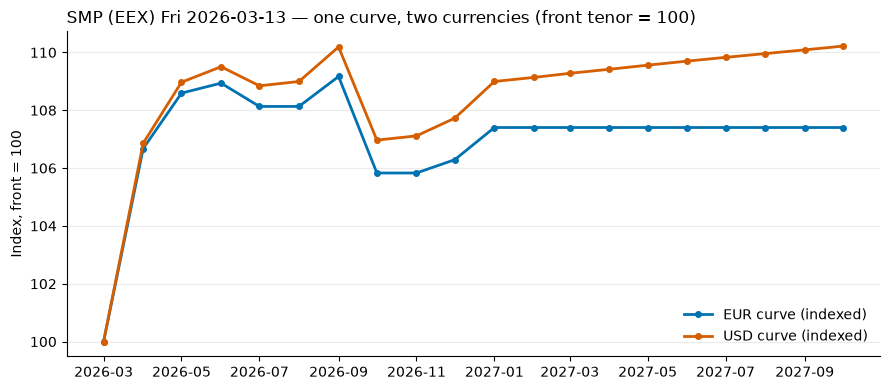

In [4]:
fx = q('''
    select make_date("Year", "Month", 1) as tenor,
           "PriceLocal"  as eur,
           "PriceUSDMT"  as usd
    from fct_futures_prices
    where "Market" = 'EEX' and "Product" = 'SMP'
      and "Timestamp" = date '2026-03-13'
    order by tenor
''')
fx["eur_idx"] = fx["eur"] / fx["eur"].iloc[0] * 100
fx["usd_idx"] = fx["usd"] / fx["usd"].iloc[0] * 100

fig, ax = plt.subplots(figsize=(9, 4))
ax.plot(fx["tenor"], fx["eur_idx"], color=BLUE,   lw=2, marker="o", ms=4, label="EUR curve (indexed)")
ax.plot(fx["tenor"], fx["usd_idx"], color=ORANGE, lw=2, marker="o", ms=4, label="USD curve (indexed)")
ax.set_title("SMP (EEX) Fri 2026-03-13 — one curve, two currencies (front tenor = 100)", loc="left")
ax.set_ylabel("Index, front = 100")
ax.spines[["top", "right"]].set_visible(False)
ax.grid(axis="y", alpha=.25)
ax.legend(frameon=False)
plt.tight_layout()

Two things the indexed view exposes:

- The gap between the curves **widens with tenor** — that is the EUR→USD
  forward curve (≈1.16 near, ≈1.20 far) doing its work. A single spot rate
  would have made the two lines identical in shape.
- From JAN2027 outward the **EUR curve is exactly flat** (carried quotes,
  again), so the USD curve's entire far-end slope is a **pure FX effect**.
  Anyone quoting far-dated SMP in USD off this feed is really quoting the
  currency market, not the dairy market — a practical reason the
  contract-month FX join matters.

## 4. Data quality — what the pipeline caught

Issues found during profiling, and where each is handled:

1. **4 error stubs** (`Error = 'Not found'`) — failed vendor requests,
   filtered in staging.
2. **4 expired-contract rows** (FEB2026: expiry 2026-02-25, before the
   sample week) — no trade date, no close; filtered in staging on a
   different condition than the error stubs. Same fate, different disease.
3. **Mixed quotation units** — FALM quoted per 100KG, everything else per
   tonne; normalised ×10 to USD/MT in the mart, guarded by an
   `accepted_values` test.
4. **Mapping key mismatch** — the mapping file's column is `RIC`, the feed
   says `Product Code`; renamed in staging.
5. **Non-unique mapping values** — several codes collapse to one product
   name (e.g. FASM/SSMP → SMP), so the mart's uniqueness key uses
   (`Timestamp`, `Market`, `Product`, `Month`, `Year`) and is tested.
6. **Low/High/Volume ≈ all null** — thin dairy futures market; `Close`
   (the official settlement) is the only fully-covered price field.
7. **Carried far-end quotes** — uniform week moves and a flat far EUR curve
   (sections 2–3); not an error, but a property analysts must know before
   reading far tenors as market signals.
8. **FX curve snapshots predate the trade week** (2025-06-04/05 vs
   2026-03) — the latest snapshot is used and flagged: with a live feed the
   join logic is unchanged, only the snapshot recency improves.

Every issue above is either filtered, normalised, tested, or documented —
none is silently ignored.

## 5. Where this could go next

With butter on the same feed, the SMP + butter pair approximates the value
of raw milk (the "milk crush"). Computing it properly needs yield
coefficients this dataset does not carry, so it is left as the natural next
analysis once product yields are available — alongside wiring the FX join
to a live forward curve and adding an exchange holiday calendar for the
forward-fill logic.